# 💼 HR Job Placement Prediction & Candidate Analytics
## End-to-End Data Analytics & Machine Learning Project

### 🎯 Objective
Analyze candidate academic performance, skills, experience, interview performance and employment factors, then build and compare machine-learning models for **job placement prediction**.

### 🧭 Project Workflow
**Data Collection → Data Understanding → Data Cleaning → Encoding → Feature Scaling → Statistical Relationship Analysis → EDA → Feature Engineering → MySQL Storage → Machine Learning → Model Evaluation → Analyst Tasks**


## 📥 Step 1 — Data Collection & Library Import


In [ ]:
"""Data collection and preprocessing"""

In [1]:
import pandas as pd
import numpy as np


In [6]:
df=pd.read_csv('HR.csv')

## 🔍 Step 2 — Data Understanding


In [ ]:
"""Data Understanding """

In [31]:
# 1. Dataset Shape and Size
print("Dataset Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Total Values:", df.size)

# 2. Data Types Validation
print("\n--- DATA TYPES ---")
print(df.dtypes)
print("\nDatatype Count:")
print(df.dtypes.value_counts())

# 3. Sample Record Inspection
print("\n--- SAMPLE RECORDS ---")
print(df.sample(5))

# 4. Null Value Distribution
print("\n--- NULL VALUE ANALYSIS ---")

null_analysis = pd.DataFrame({
    "Null_Count": df.isnull().sum(),
    "Null_Percentage": (df.isnull().mean() * 100).round(2)
})

null_analysis = null_analysis[
    null_analysis["Null_Count"] > 0
].sort_values("Null_Percentage", ascending=False)

print(null_analysis)

Dataset Shape: (51500, 26)
Rows: 51500
Columns: 26
Total Values: 1339000

--- DATA TYPES ---
age_years                      int64
gender                        object
ssc_percentage               float64
hsc_percentage               float64
degree_percentage            float64
degree_specialization         object
technical_score              float64
aptitude_score               float64
communication_score          float64
skills_match_percentage      float64
certifications_count           int64
internship_experience         object
years_of_experience            int64
career_switch_willingness     object
relevant_experience           object
previous_ctc_lpa             float64
expected_ctc_lpa             float64
company_tier                  object
job_role_match                object
competition_level             object
bond_requirement              object
notice_period_days           float64
layoff_history                object
employment_gap_months        float64
relocation_willingn

## 🧹 Step 3 — Data Cleaning & Preprocessing


In [ ]:
"""Data Cleaning & Preprocessing"""

In [ ]:
#Correct Inconsistent Categorical Labels
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip().str.lower()

In [ ]:
# Identify categorical columns before checking category values
cat_cols = df.select_dtypes(include="object").columns


In [ ]:
for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts())

In [ ]:
#Duplicate records

print(df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

0


In [37]:
# Numerical columns
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify
print(df.isnull().sum())

age_years                    0
gender                       0
ssc_percentage               0
hsc_percentage               0
degree_percentage            0
degree_specialization        0
technical_score              0
aptitude_score               0
communication_score          0
skills_match_percentage      0
certifications_count         0
internship_experience        0
years_of_experience          0
career_switch_willingness    0
relevant_experience          0
previous_ctc_lpa             0
expected_ctc_lpa             0
company_tier                 0
job_role_match               0
competition_level            0
bond_requirement             0
notice_period_days           0
layoff_history               0
employment_gap_months        0
relocation_willingness       0
status                       0
dtype: int64


In [ ]:
#Ensure Logical Consistency Across Features

In [39]:
#Check impossible percentage values:

percentage_cols = [
    "ssc_percentage",
    "hsc_percentage",
    "degree_percentage"
]

for col in percentage_cols:
    print(
        col,
        df[(df[col] < 0) | (df[col] > 100)].shape[0]
    )

ssc_percentage 0
hsc_percentage 0
degree_percentage 0


In [40]:
#Check impossible negative values:
cols = [
    "age_years",
    "years_of_experience",
    "notice_period_days",
    "employment_gap_months",
    "expected_ctc_lpa"
]

for col in cols:
    print(col, (df[col] < 0).sum())

age_years 0
years_of_experience 0
notice_period_days 0
employment_gap_months 0
expected_ctc_lpa 0


## 🔤 Step 4 — Encoding Categorical Variables


In [ ]:
# Work on a copy for encoding and scaling
df1 = df.copy()


In [ ]:
#Work on copy
# df1 = df.copy()

In [ ]:
#Encoding categorical variables (Label )
from sklearn.preprocessing import LabelEncoder
enc= LabelEncoder()

In [44]:
for i in df1.select_dtypes("object").columns:
    df1[i] = enc.fit_transform(df1[i])

## ⚖️ Step 5 — Feature Scaling for Numerical Columns

StandardScaler standardizes the selected numerical features.  
This section performs **feature scaling only**; ML modeling is kept separately later in the notebook.


In [ ]:
continous = [
    'age_years',
    'ssc_percentage',
    'hsc_percentage',
    'degree_percentage',
    'technical_score',
    'aptitude_score',
    'communication_score',
    'skills_match_percentage',
    'certifications_count',
    'years_of_experience',
    'previous_ctc_lpa',
    'expected_ctc_lpa',
    'notice_period_days',
    'employment_gap_months'
]


In [ ]:
# FEATURE SCALING FOR NUMERICAL COLUMNS
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Scale numerical columns
df_scaled = df1.copy()

df_scaled[continous] = scaler.fit_transform(
    df1[continous]
)

# Check scaled data
df_scaled.head()

## 🔗 Step 6 — Correlation & Statistical Relationship Analysis


In [ ]:
# correlation matrix
df1.corr()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
age_years,1.000000,0.002875,-0.004483,-0.001229,-0.011549,0.000806,-0.006074,-0.005783,-0.004804,0.001024,...,0.003591,0.001537,0.003775,0.004837,-0.010015,-0.000867,0.001092,0.000110,0.010433,-0.005547
gender,0.002875,1.000000,-0.005616,-0.003493,0.006692,0.006115,0.000053,-0.003094,0.000922,-0.004963,...,0.000773,0.002768,-0.005146,0.004926,-0.004550,0.001807,0.003016,0.001544,0.001753,0.002391
ssc_percentage,-0.004483,-0.005616,1.000000,0.003964,0.001382,-0.001215,0.009377,0.009996,0.004442,-0.005289,...,0.000915,0.001130,0.001189,0.000921,0.000794,-0.005228,0.004219,-0.001930,0.000971,-0.003824
hsc_percentage,-0.001229,-0.003493,0.003964,1.000000,0.001890,0.001466,0.005183,0.002740,-0.013429,-0.000191,...,-0.003361,-0.002842,-0.001671,-0.003550,0.001895,0.001548,-0.001970,-0.005775,0.002867,-0.002665
degree_percentage,-0.011549,0.006692,0.001382,0.001890,1.000000,0.000213,-0.001884,0.000995,-0.001310,-0.009130,...,0.000118,0.002457,0.004149,0.001207,-0.001165,-0.000541,-0.000056,0.004848,0.001122,-0.007228
degree_specialization,0.000806,0.006115,-0.001215,0.001466,0.000213,1.000000,0.002968,-0.005224,-0.005478,0.000068,...,-0.001701,-0.004314,0.018489,-0.001709,0.007754,-0.003925,-0.002115,-0.002658,0.000178,-0.001443
technical_score,-0.006074,0.000053,0.009377,0.005183,-0.001884,0.002968,1.000000,0.001158,-0.003297,0.004362,...,-0.003071,-0.002741,-0.003186,-0.002450,-0.005126,0.001992,-0.008089,-0.002468,0.001949,0.403706
aptitude_score,-0.005783,-0.003094,0.009996,0.002740,0.000995,-0.005224,0.001158,1.000000,0.000586,0.002657,...,-0.001643,0.006864,0.001578,0.003348,-0.000341,-0.003752,-0.004885,0.005427,0.007110,0.039565
communication_score,-0.004804,0.000922,0.004442,-0.013429,-0.001310,-0.005478,-0.003297,0.000586,1.000000,0.001367,...,0.003539,0.006126,0.006426,0.002627,-0.001271,0.007045,-0.005574,0.003618,0.001967,0.097831
skills_match_percentage,0.001024,-0.004963,-0.005289,-0.000191,-0.009130,0.000068,0.004362,0.002657,0.001367,1.000000,...,-0.005866,0.003676,0.003706,0.002560,0.002327,0.000514,-0.000742,-0.003504,-0.000583,0.198423


In [ ]:
# logic to find columns with low correlation
corr = df1.corr(numeric_only=True)

selected_columns = []

for col in corr.columns:

    other_corr = corr[col].drop(index=col).dropna()

    if (other_corr.abs() < 0.05).all():
        selected_columns.append(col)

        print(f"\n{col}")


age_years

gender

ssc_percentage

hsc_percentage

degree_percentage

degree_specialization

aptitude_score

certifications_count

company_tier


In [ ]:
 #Finding the columns with relation to all other columns

In [64]:
cat= [
    'gender',
    'degree_specialization',
    'internship_experience',
    'career_switch_willingness',
    'relevant_experience',
    'company_tier',
    'job_role_match',
    'competition_level',
    'bond_requirement',
    'layoff_history',
    'relocation_willingness',
    'status'
]

In [65]:
continous = [
    'age_years',
    'ssc_percentage',
    'hsc_percentage',
    'degree_percentage',
    'technical_score',
    'aptitude_score',
    'communication_score',
    'skills_match_percentage',
    'certifications_count',
    'years_of_experience',
    'previous_ctc_lpa',
    'expected_ctc_lpa',
    'notice_period_days',
    'employment_gap_months'
]

<Axes: >

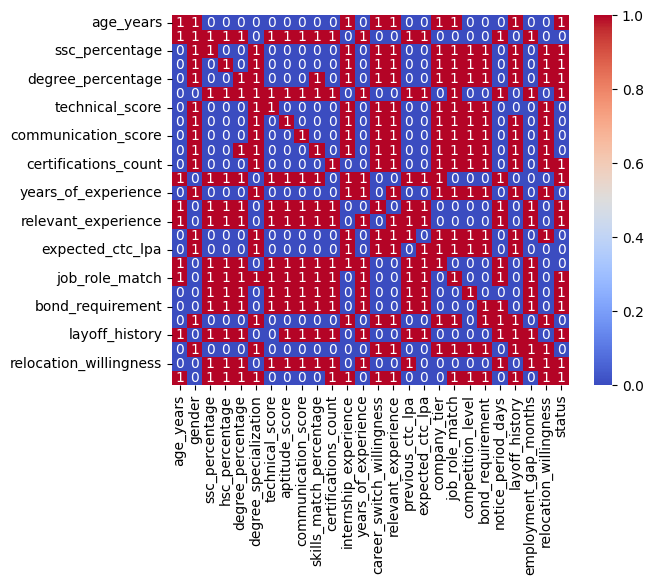

In [70]:
from scipy import stats
continous = [
    'age_years',
    'ssc_percentage',
    'hsc_percentage',
    'degree_percentage',
    'technical_score',
    'aptitude_score',
    'communication_score',
    'skills_match_percentage',
    'certifications_count',
    'years_of_experience',
    'previous_ctc_lpa',
    'expected_ctc_lpa',
    'notice_period_days',
    'employment_gap_months'
]
cat= [
    'gender',
    'degree_specialization',
    'internship_experience',
    'career_switch_willingness',
    'relevant_experience',
    'company_tier',
    'job_role_match',
    'competition_level',
    'bond_requirement',
    'layoff_history',
    'relocation_willingness',
    'status'
]

#continous vs continous (two sample)
def continous_vs_continous(col1,col2):
  t=0
  f=0
  for i in range(31):
    samp1=df[col1].sample(frac=0.03)
    samp2=df[col2].sample(frac=0.03)
    ttest,pvalue=stats.ttest_ind(samp1,samp2)
    if pvalue<0.1:
      f=f+1
    else:
      t=t+1

  if t>f:
    return True
  else:
    return False
#continous(col1) vs category(col2)
def continous_vs_category(col1,col2):
  group=df[col2].unique()
  data={}
  for i in group:
    data[i]=df[col1][df[col2]==i]
  fvalue,pvalue=stats.f_oneway(*[i for i in data.values()])
  return False if pvalue<0.1 else True

#cat vs cat
def cat_vs_cat(col1,col2):
    return True if stats.chi2_contingency(pd.crosstab(df[col1],df[col2]))[1] < 0.1 else False

final={}
for i in df.columns:
    final[i]={}
    for j in df.columns:
        if (i in continous) and (j in continous):
            result = continous_vs_continous(i,j)
        elif (i in continous) and (j in cat):
            result = continous_vs_category(i,j)
        elif (i in cat) and (j in continous):
            result = continous_vs_category(j,i)
        elif (i in cat) and (j in cat):
            result=cat_vs_cat(i,j)
        if result:
            final[i][j]=1 #True
        else:
            final[i][j]=0 #False

final_df = pd.DataFrame(final)
final_df

import seaborn as sns
sns.heatmap(
    final_df,
    annot=True,
    cmap="coolwarm",
    annot_kws={"size": 10},
)

In [74]:
target = "status"

direct_relationship = []
indirect_relationship = []
no_relationship = []

# ------------------------------------
# 1. Find DIRECT relationships
# ------------------------------------
for col in df.columns:

    if col == target:
        continue

    if final_df.loc[target, col] == 1:
        direct_relationship.append(col)


# ------------------------------------
# 2. Find INDIRECT relationships
# ------------------------------------
for col in df.columns:

    if col == target:
        continue

    # Skip direct relationships
    if col in direct_relationship:
        continue

    indirect_via = []

    # Check relationship with features
    # that directly relate to target
    for direct_col in direct_relationship:

        if final_df.loc[direct_col, col] == 1:
            indirect_via.append(direct_col)

    if len(indirect_via) > 0:
        indirect_relationship.append((col, indirect_via))

    else:
        no_relationship.append(col)


# ------------------------------------
# PRINT RESULTS
# ------------------------------------

print("DIRECT RELATIONSHIP WITH TARGET:")
for col in direct_relationship:
    print(col)


print("\nINDIRECT RELATIONSHIP WITH TARGET:")
for col, via in indirect_relationship:
    print(f"{col} --> via {', '.join(via)}")


print("\nNO DETECTED RELATIONSHIP WITH TARGET:")
for col in no_relationship:
    print(col)

DIRECT RELATIONSHIP WITH TARGET:
age_years
ssc_percentage
hsc_percentage
degree_percentage
degree_specialization
certifications_count
internship_experience
career_switch_willingness
relevant_experience
job_role_match
competition_level
bond_requirement
layoff_history
relocation_willingness

INDIRECT RELATIONSHIP WITH TARGET:
gender --> via age_years, ssc_percentage, hsc_percentage, degree_percentage, certifications_count
technical_score --> via degree_specialization, internship_experience, career_switch_willingness, relevant_experience, job_role_match, competition_level, bond_requirement, relocation_willingness
aptitude_score --> via degree_specialization, internship_experience, career_switch_willingness, relevant_experience, job_role_match, competition_level, bond_requirement, layoff_history, relocation_willingness
communication_score --> via degree_specialization, internship_experience, career_switch_willingness, relevant_experience, job_role_match, competition_level, bond_requirement

In [75]:
import pandas as pd

summary = []

# Direct
for col in direct_relationship:
    summary.append({
        "Column": col,
        "Relationship": "Direct",
        "Via": "-"
    })

# Indirect
for col, via in indirect_relationship:
    summary.append({
        "Column": col,
        "Relationship": "Indirect",
        "Via": ", ".join(via)
    })

# Neither
for col in no_relationship:
    summary.append({
        "Column": col,
        "Relationship": "No Direct/Indirect Relationship",
        "Via": "-"
    })

relationship_df = pd.DataFrame(summary)

relationship_df

,Column,Relationship,Via
0,age_years,Direct,-
1,ssc_percentage,Direct,-
2,hsc_percentage,Direct,-
3,degree_percentage,Direct,-
4,degree_specialization,Direct,-
5,certifications_count,Direct,-
6,internship_experience,Direct,-
7,career_switch_willingness,Direct,-
8,relevant_experience,Direct,-
9,job_role_match,Direct,-


## 📊 Step 7 — Exploratory Data Analysis (EDA)

The complete original EDA code is preserved below, including candidate/interview/skills/placement analyses and visualizations.


In [ ]:
"""4: EXPLORATORY DATA ANALYSIS (EDA)"""


1. INTERVIEW SCORE VS PLACEMENT
--------------------------------------------------
             mean  median  count
status                          
not placed  64.69   64.62  34870
placed      69.15   68.94  15130


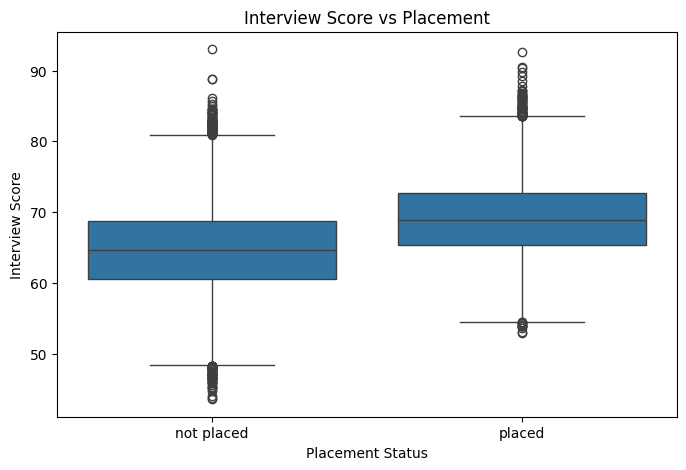


2. SKILLS MATCH % VS PLACEMENT
--------------------------------------------------
            mean  median  count
status                         
not placed  72.4   72.58  34870
placed      77.5   77.23  15130


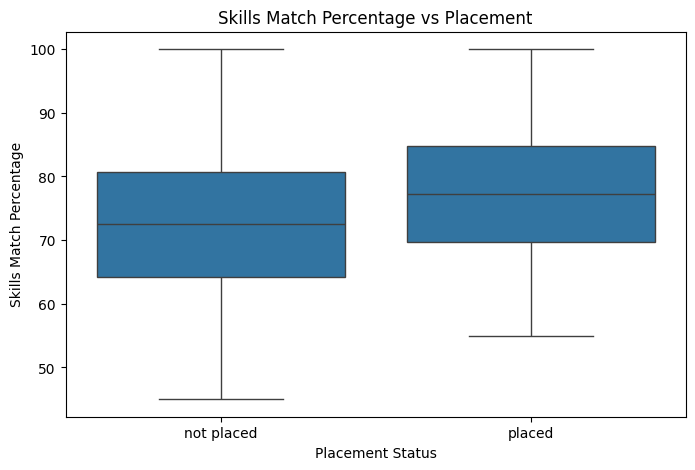


3. COMPANY TIER VS PLACEMENT RATE
--------------------------------------------------
status        not placed  placed
company_tier                    
tier 1             70.06   29.94
tier 2             69.58   30.42
tier 3             69.46   30.54


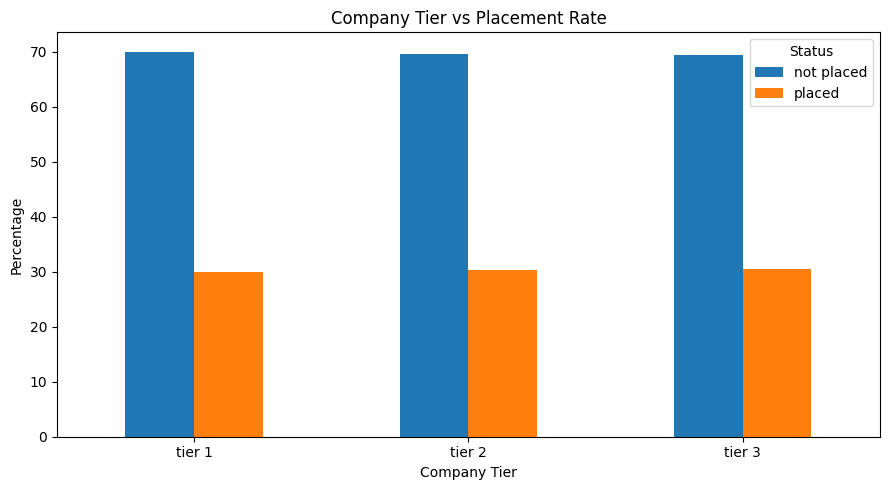


4. EXPERIENCE VS PLACEMENT
--------------------------------------------------
            mean  median  count
status                         
not placed  1.19     1.0  34870
placed      2.19     2.0  15130

Placement percentage by experience:
status               not placed  placed
years_of_experience                    
0                         86.22   13.78
1                         75.87   24.13
2                         63.91   36.09
3                         50.99   49.01
4                         42.28   57.72
5                         35.42   64.58


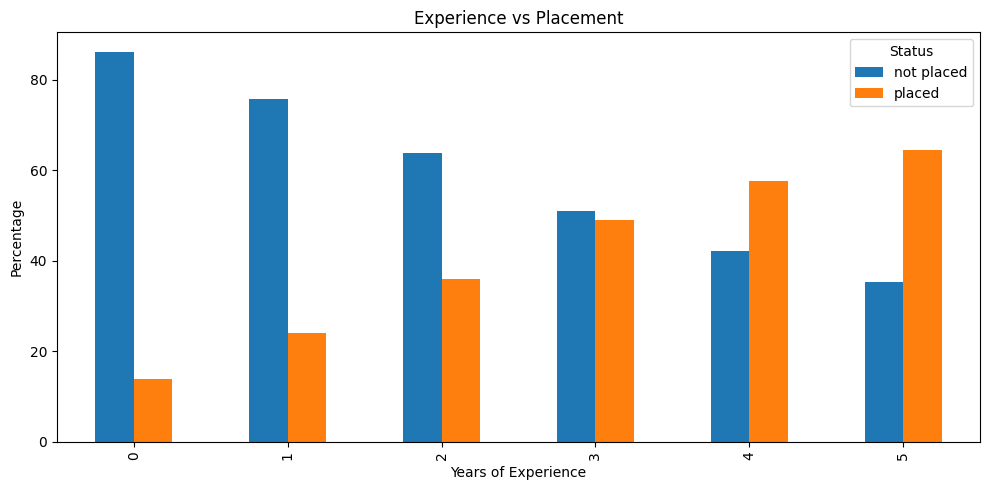


5. COMPETITION LEVEL VS PLACEMENT
--------------------------------------------------
status             not placed  placed
competition_level                    
high                    76.22   23.78
low                     68.13   31.87
medium                  68.10   31.90


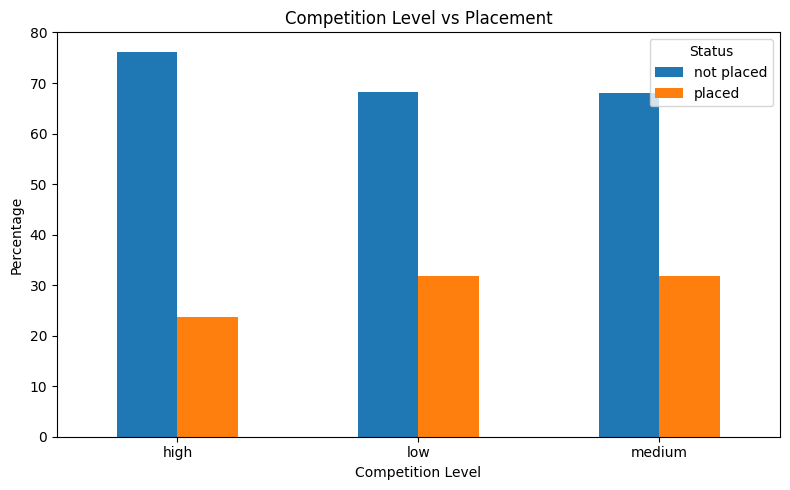


6. NUMERICAL FEATURE CORRELATION
--------------------------------------------------
                         age_years  ssc_percentage  hsc_percentage  \
age_years                     1.00           -0.00           -0.00   
ssc_percentage               -0.00            1.00            0.00   
hsc_percentage               -0.00            0.00            1.00   
degree_percentage            -0.01            0.00            0.00   
technical_score              -0.01            0.01            0.01   
aptitude_score               -0.01            0.01            0.00   
communication_score          -0.00            0.00           -0.01   
skills_match_percentage       0.00           -0.01           -0.00   
certifications_count         -0.01           -0.01            0.00   
years_of_experience           0.00           -0.01           -0.00   
previous_ctc_lpa             -0.00           -0.00            0.01   
expected_ctc_lpa              0.00            0.00           -0.00   
notic

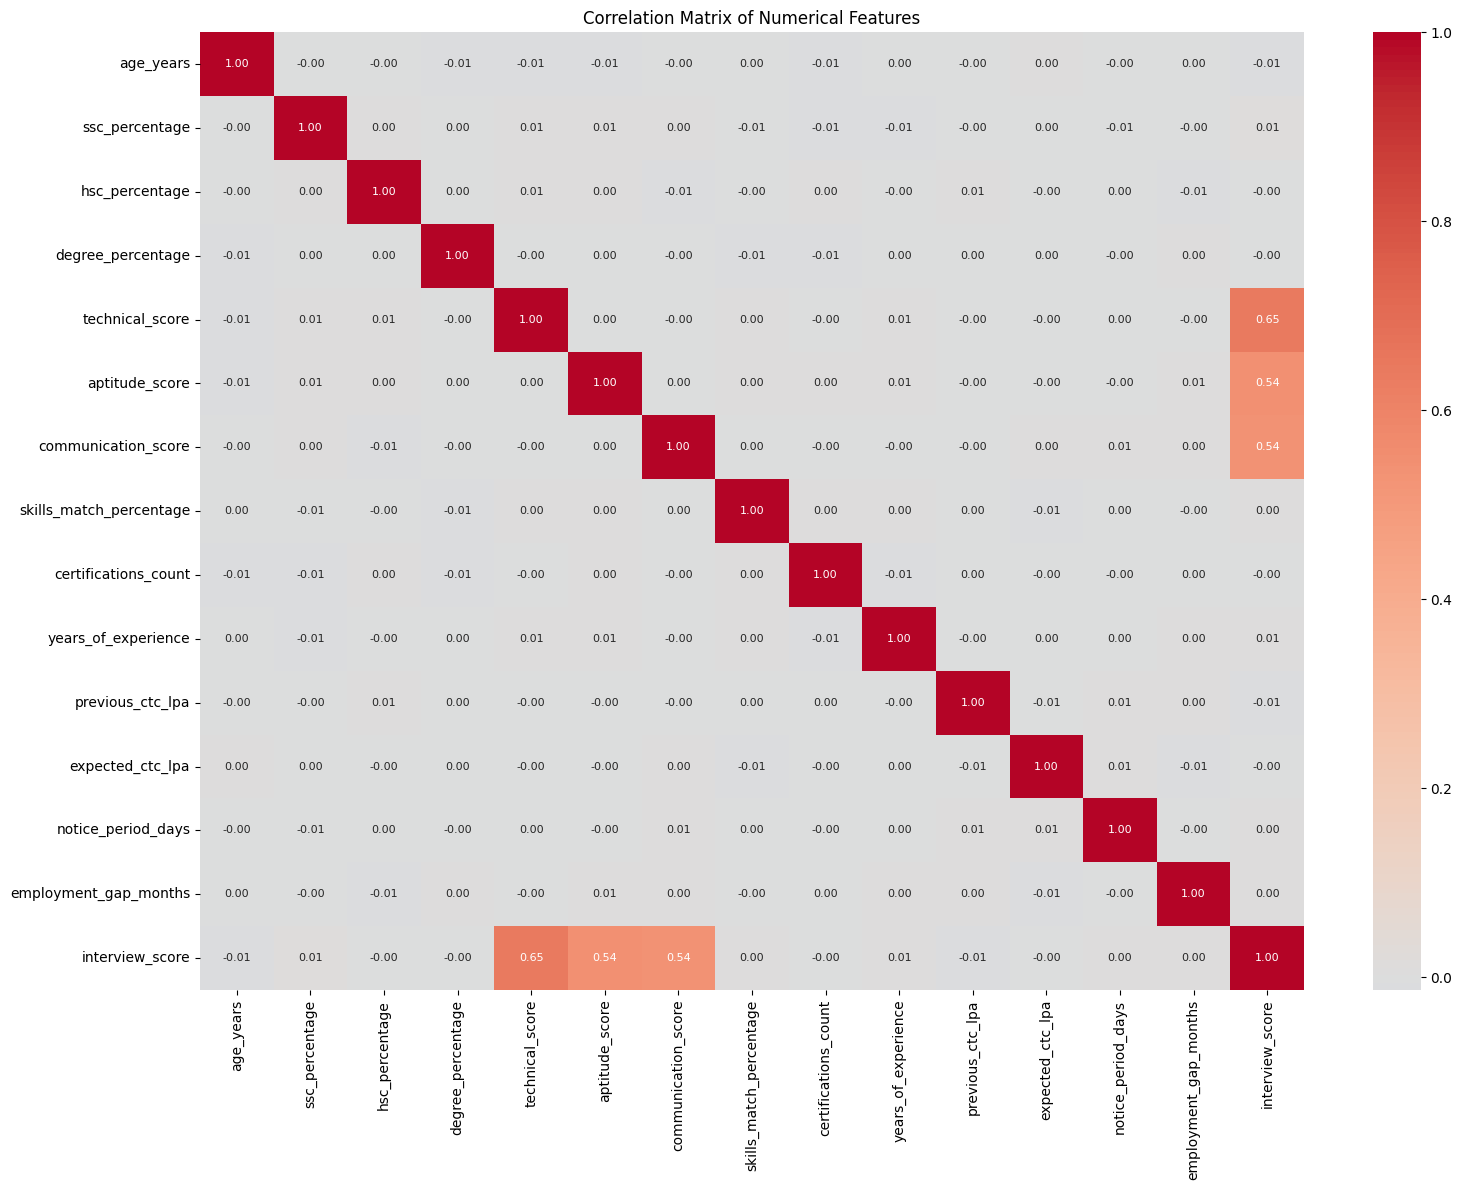

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# ==========================================================

# Work on a copy
eda_df = df.copy()

# ----------------------------------------------------------
# Clean categorical labels
# ----------------------------------------------------------

cat_cols = eda_df.select_dtypes(include="object").columns

for col in cat_cols:
    eda_df[col] = (
        eda_df[col]
        .str.strip()
        .str.lower()
    )


# ----------------------------------------------------------
# Create Interview Score
# Average of technical, aptitude and communication scores
# ----------------------------------------------------------

eda_df["interview_score"] = eda_df[
    [
        "technical_score",
        "aptitude_score",
        "communication_score"
    ]
].mean(axis=1)


# ==========================================================
# 1. INTERVIEW SCORE VS JOB ACCEPTANCE / PLACEMENT
# ==========================================================

print("\n1. INTERVIEW SCORE VS PLACEMENT")
print("-" * 50)

print(
    eda_df.groupby("status")["interview_score"]
    .agg(["mean", "median", "count"])
    .round(2)
)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=eda_df,
    x="status",
    y="interview_score"
)

plt.title("Interview Score vs Placement")
plt.xlabel("Placement Status")
plt.ylabel("Interview Score")
plt.show()


# ==========================================================
# 2. SKILLS MATCH PERCENTAGE VS PLACEMENT
# ==========================================================

print("\n2. SKILLS MATCH % VS PLACEMENT")
print("-" * 50)

print(
    eda_df.groupby("status")["skills_match_percentage"]
    .agg(["mean", "median", "count"])
    .round(2)
)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=eda_df,
    x="status",
    y="skills_match_percentage"
)

plt.title("Skills Match Percentage vs Placement")
plt.xlabel("Placement Status")
plt.ylabel("Skills Match Percentage")
plt.show()


# ==========================================================
# 3. COMPANY TIER VS PLACEMENT RATE
# ==========================================================

print("\n3. COMPANY TIER VS PLACEMENT RATE")
print("-" * 50)

company_tier_rate = pd.crosstab(
    eda_df["company_tier"],
    eda_df["status"],
    normalize="index"
) * 100

print(company_tier_rate.round(2))

company_tier_rate.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Company Tier vs Placement Rate")
plt.xlabel("Company Tier")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Status")
plt.tight_layout()
plt.show()


# ==========================================================
# 4. EXPERIENCE VS PLACEMENT
# ==========================================================

print("\n4. EXPERIENCE VS PLACEMENT")
print("-" * 50)

print(
    eda_df.groupby("status")["years_of_experience"]
    .agg(["mean", "median", "count"])
    .round(2)
)

experience_rate = pd.crosstab(
    eda_df["years_of_experience"],
    eda_df["status"],
    normalize="index"
) * 100

print("\nPlacement percentage by experience:")
print(experience_rate.round(2))

experience_rate.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Experience vs Placement")
plt.xlabel("Years of Experience")
plt.ylabel("Percentage")
plt.legend(title="Status")
plt.tight_layout()
plt.show()


# ==========================================================
# 5. COMPETITION LEVEL VS JOB ACCEPTANCE
# ==========================================================

print("\n5. COMPETITION LEVEL VS PLACEMENT")
print("-" * 50)

competition_rate = pd.crosstab(
    eda_df["competition_level"],
    eda_df["status"],
    normalize="index"
) * 100

print(competition_rate.round(2))

competition_rate.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Competition Level vs Placement")
plt.xlabel("Competition Level")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Status")
plt.tight_layout()
plt.show()


# ==========================================================
# 6. CORRELATION ANALYSIS - NUMERICAL FEATURES
# ==========================================================

print("\n6. NUMERICAL FEATURE CORRELATION")
print("-" * 50)

corr = eda_df.corr(numeric_only=True)

print(corr.round(2))

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    annot_kws={"size": 8}
)

plt.title("Correlation Matrix of Numerical Features")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 🛠️ Step 8 — Feature Engineering


In [ ]:
"""FEATURE ENGINEERING"""

In [79]:
import pandas as pd
import numpy as np

df_feature = df.copy()


# ==========================================================
# 1. EXPERIENCE CATEGORY
# Fresher / Junior / Senior
# ==========================================================

df_feature["experience_category"] = pd.cut(
    df_feature["years_of_experience"],
    bins=[-1, 0, 3, np.inf],
    labels=["Fresher", "Junior", "Senior"]
)


# ==========================================================
# 2. ACADEMIC PERFORMANCE
# Average of SSC, HSC and Degree percentage
# ==========================================================

df_feature["academic_score"] = df_feature[
    [
        "ssc_percentage",
        "hsc_percentage",
        "degree_percentage"
    ]
].mean(axis=1)


df_feature["academic_performance_band"] = pd.cut(
    df_feature["academic_score"],
    bins=[0, 60, 75, 100],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)


# ==========================================================
# 3. SKILLS MATCH LEVEL
# Low / Medium / High
# ==========================================================

df_feature["skills_match_level"] = pd.cut(
    df_feature["skills_match_percentage"],
    bins=[0, 50, 75, 100],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)


# ==========================================================
# 4. INTERVIEW PERFORMANCE CATEGORY
# ==========================================================

# Combined interview score
df_feature["interview_score"] = df_feature[
    [
        "technical_score",
        "aptitude_score",
        "communication_score"
    ]
].mean(axis=1)


df_feature["interview_performance"] = pd.cut(
    df_feature["interview_score"],
    bins=[0, 50, 75, 100],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)


# ==========================================================
# 5. PLACEMENT READINESS SCORE
# ==========================================================

df_feature["placement_readiness_score"] = (

    # Academic performance - 25%
    df_feature["academic_score"] * 0.25

    +

    # Skills match - 30%
    df_feature["skills_match_percentage"] * 0.30

    +

    # Technical score - 20%
    df_feature["technical_score"] * 0.20

    +

    # Aptitude score - 10%
    df_feature["aptitude_score"] * 0.10

    +

    # Communication score - 15%
    df_feature["communication_score"] * 0.15
)


# Round score
df_feature["placement_readiness_score"] = (
    df_feature["placement_readiness_score"].round(2)
)


# ==========================================================
# DISPLAY NEW FEATURES
# ==========================================================

new_features = [
    "years_of_experience",
    "experience_category",
    "academic_score",
    "academic_performance_band",
    "skills_match_percentage",
    "skills_match_level",
    "interview_score",
    "interview_performance",
    "placement_readiness_score",
    "status"
]

print(df_feature[new_features].head(10))

   years_of_experience experience_category  academic_score  \
0                    1              Junior       74.920254   
1                    0             Fresher       68.650839   
2                    1              Junior       77.641017   
3                    0             Fresher       75.329142   
4                    0             Fresher       69.021094   
5                    1              Junior       68.332356   
6                    1              Junior       75.891144   
7                    3              Junior       71.506613   
8                    2              Junior       76.016935   
9                    2              Junior       73.947321   

  academic_performance_band  skills_match_percentage skills_match_level  \
0                    Medium                79.548913               High   
1                    Medium                73.316134             Medium   
2                      High                75.466980               High   
3                

## 🗄️ Step 9 — Data Storage in MySQL


In [ ]:
"""DATA STORAGE IN MYSQL"""

In [81]:
# ==========================================================
# STEP 6: DATA STORAGE IN MYSQL
# ==========================================================

# Install once if required:
# pip install sqlalchemy pymysql

import pandas as pd
from sqlalchemy import create_engine, text


# ==========================================================
# 1. MYSQL CONNECTION DETAILS
# ==========================================================

username = "root"
password = "root"
host = "localhost"
port = "3306"
database = "hr_job_placement"


# ==========================================================
# 2. CONNECT TO MYSQL SERVER
# Create database if it does not exist
# ==========================================================

server_engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/"
)

with server_engine.connect() as connection:

    connection.execute(
        text(
            f"CREATE DATABASE IF NOT EXISTS {database}"
        )
    )

    connection.commit()

print("Database created successfully!")


# ==========================================================
# 3. CONNECT TO HR DATABASE
# ==========================================================

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

print("MySQL connected successfully!")


# ==========================================================
# 4. PREPARE FINAL DATAFRAME
# ==========================================================

df_sql = df_feature.copy()

# Convert pandas category columns to string
category_cols = df_sql.select_dtypes(
    include="category"
).columns

for col in category_cols:
    df_sql[col] = df_sql[col].astype(str)


# ==========================================================
# 5. STORE DATAFRAME IN MYSQL
# ==========================================================

df_sql.to_sql(
    name="job_placement_data",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=1000
)

print("Dataset stored successfully in MySQL!")


# ==========================================================
# 6. VERIFY DATA FROM MYSQL
# ==========================================================

query = """
SELECT *
FROM job_placement_data
LIMIT 10;
"""

check_df = pd.read_sql(query, engine)

print(check_df)


# ==========================================================
# 7. CHECK TOTAL ROWS
# ==========================================================

query = """
SELECT COUNT(*) AS total_records
FROM job_placement_data;
"""

count_df = pd.read_sql(query, engine)

print(count_df)

Database created successfully!
MySQL connected successfully!
Dataset stored successfully in MySQL!
   age_years  gender  ssc_percentage  hsc_percentage  degree_percentage  \
0         27    male       65.061656       83.842578          75.856526   
1         24    male       67.885626       64.973305          73.093588   
2         33  female       73.892471       68.834121          90.196460   
3         31    male       74.145568       76.255126          75.586731   
4         28    male       60.475937       65.786336          80.801010   
5         33  female       60.641768       66.151843          78.203455   
6         25  female       78.224191       69.578282          79.870959   
7         27  female       69.977809       69.111350          75.430679   
8         30  female       69.535754       78.757507          79.757543   
9         23  female       70.972461       78.101606          72.767897   

    degree_specialization  technical_score  aptitude_score  \
0        comp

## 🤖 Step 10 — Machine Learning Modeling

Five classification algorithms are compared:
**Logistic Regression, Decision Tree, Random Forest, KNN, and Gradient Boosting.**


In [ ]:
"""Machine Learning Modeling """

In [ ]:
x = df1.drop(columns=['status'])
y = df1['status']

In [ ]:
# Train-Test Split for ML Modeling
from sklearn.model_selection import train_test_split

x = df_scaled.drop(columns=["status"])
y = df_scaled["status"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("x_train:", x_train.shape)
print("x_test :", x_test.shape)


In [89]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ---------------------------------------------------------
# 1. DEFINE 5 ML MODELS
# ---------------------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}


# ---------------------------------------------------------
# 2. TRAIN AND EVALUATE MODELS
# ---------------------------------------------------------

results = []

for name, model in models.items():

    # Train
    model.fit(x_train, y_train)

    # Predict
    y_pred = model.predict(x_test)

    # Classification Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Additional Error Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store Results
    results.append({
        "Model": name,
        "Accuracy": accuracy * 100,
        "Precision": precision * 100,
        "Recall": recall * 100,
        "F1 Score": f1 * 100,
        "MAE": mae,
        "MSE": mse,
        "R2": r2
    })


# ---------------------------------------------------------
# 3. RESULT DATAFRAME
# ---------------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)


# Round values
results_df[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "MAE",
        "MSE",
        "R2"
    ]
] = results_df[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "MAE",
        "MSE",
        "R2"
    ]
].round(4)


print(results_df)

                 Model  Accuracy  Precision   Recall  F1 Score     MAE  \
0    Gradient Boosting     89.25    84.9016  78.4204   81.5324  0.1075   
1        Random Forest     88.97    86.0517  75.8427   80.6253  0.1103   
2  Logistic Regression     86.43    79.4981  74.3225   76.8232  0.1357   
3        Decision Tree     82.54    71.1082  71.2492   71.1786  0.1746   
4                  KNN     79.99    68.7660  62.0621   65.2423  0.2001   

      MSE      R2  
0  0.1075  0.4906  
1  0.1103  0.4773  
2  0.1357  0.3570  
3  0.1746  0.1726  
4  0.2001  0.0518  


In [90]:
best = results_df.iloc[0]

print("\nHighest Test Accuracy:")
print("Model:", best["Model"])
print("Accuracy:", best["Accuracy"], "%")
print("Precision:", best["Precision"], "%")
print("Recall:", best["Recall"], "%")
print("F1 Score:", best["F1 Score"], "%")


Highest Test Accuracy:
Model: Gradient Boosting
Accuracy: 89.25 %
Precision: 84.9016 %
Recall: 78.4204 %
F1 Score: 81.5324 %


### 📌 Model Evaluation Note
For this **classification** project, Accuracy, Precision, Recall and F1 Score are the primary evaluation metrics.  
MAE, MSE and R² are retained because they are present in your project code, but they are regression-oriented metrics.


## 📈 Step 11 — Analyst Tasks: EDA & ML Analytics


In [ ]:
"""# STEP 8: ANALYST TASKS - EDA & ML ANALYTICS"""

Original status values:
['not placed' 'placed']

Encoded status values:
status
0    34870
1    15130
Name: count, dtype: int64

1. ACADEMIC SCORES VS PLACEMENT OUTCOME
            ssc_percentage  hsc_percentage  degree_percentage
status                                                       
Not Placed           70.03           72.07              74.04
Placed               69.97           72.03              73.93


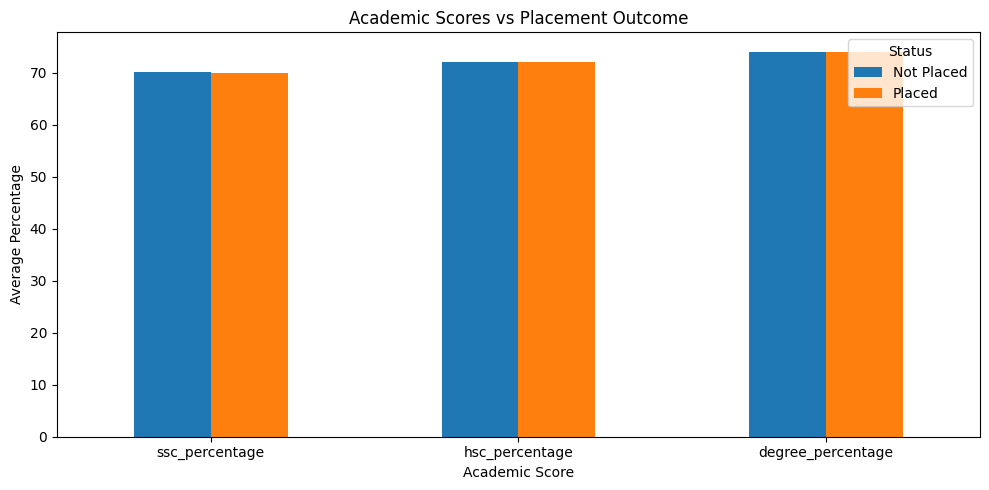


2. SKILLS MATCH VS INTERVIEW PERFORMANCE
                         skills_match_percentage  interview_score
skills_match_percentage                    1.000            0.005
interview_score                            0.005            1.000


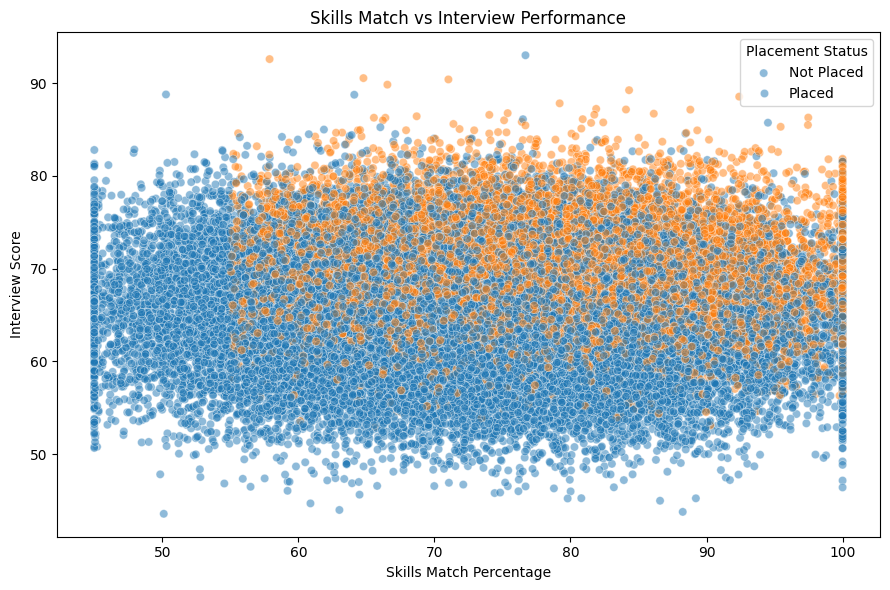


3. CERTIFICATION IMPACT ON JOB ACCEPTANCE
   certifications_count  count  acceptance_rate
0                     0  12340            30.51
1                     1  17233            30.22
2                     2  12096            30.08
3                     3   5632            30.49
4                     4   1984            31.00
5                     5    557            26.03
6                     6    116            30.17
7                     7     33            15.15
8                     8      9            33.33


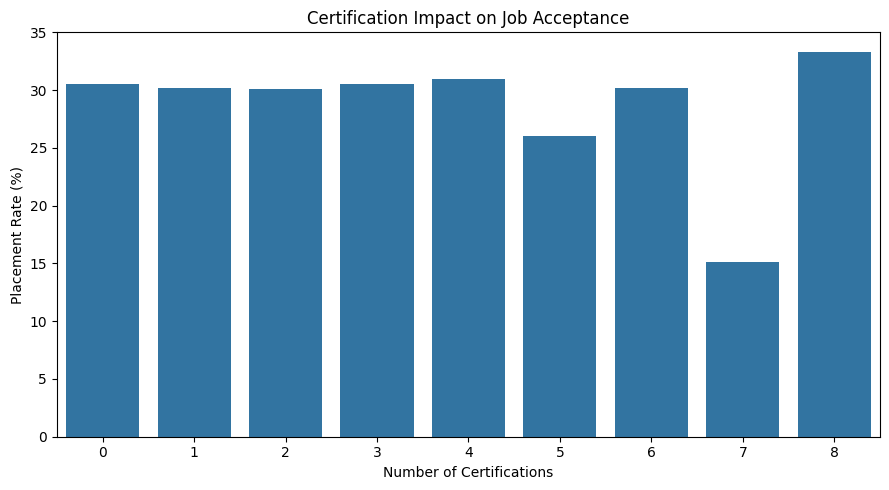


4. ACCEPTANCE RATE BY COMPANY TIER
  company_tier  count  acceptance_rate
0       tier 1  19305            29.94
1       tier 2  18483            30.42
2       tier 3  12212            30.54


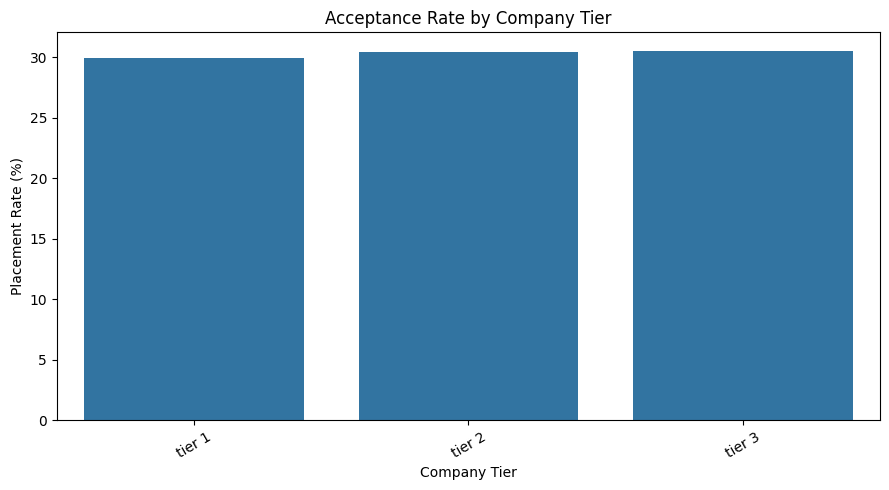


5. EXPERIENCE VS PLACEMENT SUCCESS
   years_of_experience  count  placement_rate
0                    0  14952           13.78
1                    1  13508           24.13
2                    2   9966           36.09
3                    3   6538           49.01
4                    4   3548           57.72
5                    5   1488           64.58


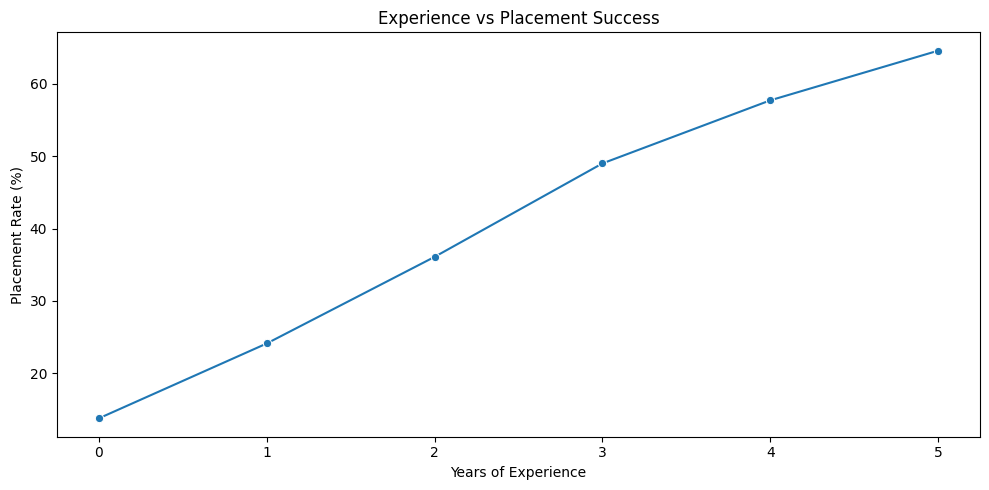


6. INTERVIEW SCORE VS PLACEMENT RATE
  interview_score_band  count  placement_rate
0                 <=50    172            0.00
1                51-60   8030            6.58
2                61-70  28813           28.34
3                71-80  12426           48.66
4                81-90    555           69.37
5                  >90      4           75.00


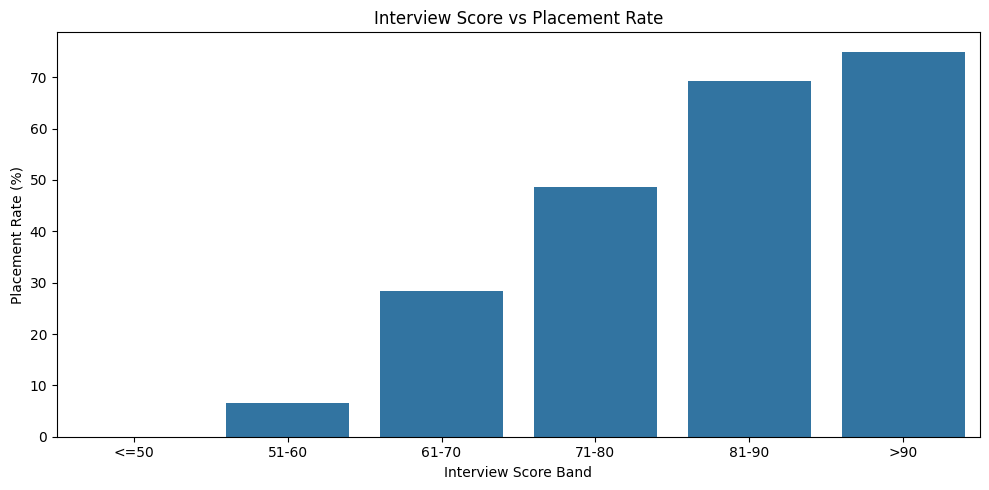


7. EMPLOYABILITY TEST SCORE ANALYSIS
             mean  median   std  count
status                                
Not Placed  66.62   66.57  5.17  34870
Placed      71.24   71.16  4.71  15130


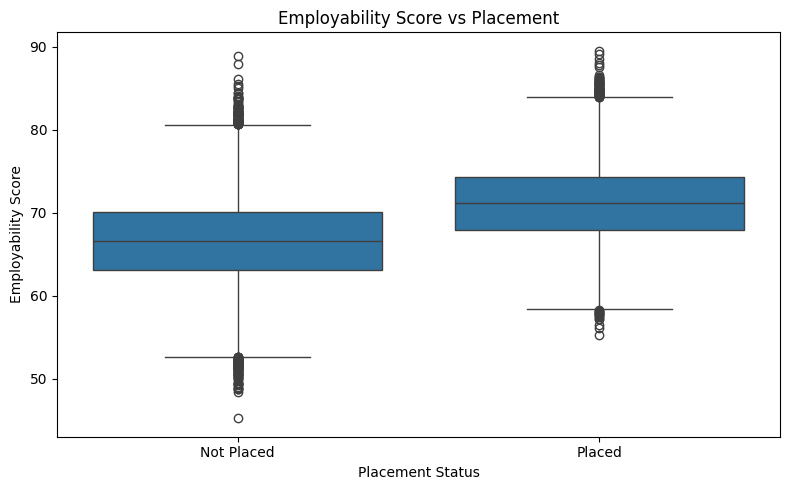


8. OVERALL PLACEMENT RATE
Overall Placement Rate: 30.26%

ANALYST TASKS COMPLETED

1. Academic Scores vs Placement Outcome
2. Skills Match vs Interview Performance
3. Certification Impact on Job Acceptance
4. Acceptance Rate by Company Tier
5. Experience vs Placement Success
6. Interview Score vs Placement Rate
7. Employability Test Score Analysis
8. Overall Placement Rate



In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# STEP 8: ANALYST TASKS - EDA & ML ANALYTICS
# ============================================================

analysis_df = df_feature.copy()


# ============================================================
# 0. PREPARE TARGET COLUMN
# Placed     -> 1
# Not Placed -> 0
# ============================================================

print("Original status values:")
print(analysis_df["status"].unique())


# Convert status only if it is not already numeric
if not pd.api.types.is_numeric_dtype(analysis_df["status"]):

    analysis_df["status"] = (
        analysis_df["status"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({
            "placed": 1,
            "not placed": 0
        })
    )


print("\nEncoded status values:")
print(analysis_df["status"].value_counts(dropna=False))


# Check for unmapped/missing target values
if analysis_df["status"].isnull().sum() > 0:

    print(
        "\nWARNING:",
        analysis_df["status"].isnull().sum(),
        "missing/unmapped values found in status."
    )


# ============================================================
# CREATE INTERVIEW SCORE IF NOT ALREADY AVAILABLE
# ============================================================

if "interview_score" not in analysis_df.columns:

    analysis_df["interview_score"] = analysis_df[
        [
            "technical_score",
            "aptitude_score",
            "communication_score"
        ]
    ].mean(axis=1)


# ============================================================
# A. CANDIDATE PERFORMANCE ANALYSIS
# ============================================================


# ------------------------------------------------------------
# 1. ACADEMIC SCORES VS PLACEMENT OUTCOME
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("1. ACADEMIC SCORES VS PLACEMENT OUTCOME")
print("=" * 60)


academic_cols = [
    "ssc_percentage",
    "hsc_percentage",
    "degree_percentage"
]


academic_result = (
    analysis_df
    .groupby("status")[academic_cols]
    .mean()
    .round(2)
)


# Rename index for easy understanding
academic_result = academic_result.rename(
    index={
        0: "Not Placed",
        1: "Placed"
    }
)


print(academic_result)


academic_result.T.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Academic Scores vs Placement Outcome")
plt.xlabel("Academic Score")
plt.ylabel("Average Percentage")
plt.xticks(rotation=0)
plt.legend(title="Status")
plt.tight_layout()
plt.show()



# ============================================================
# 2. SKILLS MATCH VS INTERVIEW PERFORMANCE
# ============================================================

print("\n" + "=" * 60)
print("2. SKILLS MATCH VS INTERVIEW PERFORMANCE")
print("=" * 60)


skills_interview_corr = analysis_df[
    [
        "skills_match_percentage",
        "interview_score"
    ]
].corr()


print(skills_interview_corr.round(3))


plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=analysis_df,
    x="skills_match_percentage",
    y="interview_score",
    hue="status",
    alpha=0.5
)

plt.title("Skills Match vs Interview Performance")
plt.xlabel("Skills Match Percentage")
plt.ylabel("Interview Score")

plt.legend(
    title="Placement Status",
    labels=["Not Placed", "Placed"]
)

plt.tight_layout()
plt.show()



# ============================================================
# 3. CERTIFICATION IMPACT ON JOB ACCEPTANCE
# ============================================================

print("\n" + "=" * 60)
print("3. CERTIFICATION IMPACT ON JOB ACCEPTANCE")
print("=" * 60)


certification_analysis = (
    analysis_df
    .groupby("certifications_count")["status"]
    .agg(["mean", "count"])
    .reset_index()
)


certification_analysis["acceptance_rate"] = (
    certification_analysis["mean"] * 100
)


print(
    certification_analysis[
        [
            "certifications_count",
            "count",
            "acceptance_rate"
        ]
    ].round(2)
)


plt.figure(figsize=(9, 5))

sns.barplot(
    data=certification_analysis,
    x="certifications_count",
    y="acceptance_rate"
)

plt.title("Certification Impact on Job Acceptance")
plt.xlabel("Number of Certifications")
plt.ylabel("Placement Rate (%)")
plt.tight_layout()
plt.show()



# ============================================================
# B. PLACEMENT & ACCEPTANCE ANALYSIS
# ============================================================


# ============================================================
# 4. ACCEPTANCE RATE BY COMPANY TIER
# ============================================================

print("\n" + "=" * 60)
print("4. ACCEPTANCE RATE BY COMPANY TIER")
print("=" * 60)


company_analysis = (
    analysis_df
    .groupby("company_tier")["status"]
    .agg(["mean", "count"])
    .reset_index()
)


company_analysis["acceptance_rate"] = (
    company_analysis["mean"] * 100
)


print(
    company_analysis[
        [
            "company_tier",
            "count",
            "acceptance_rate"
        ]
    ].round(2)
)


plt.figure(figsize=(9, 5))

sns.barplot(
    data=company_analysis,
    x="company_tier",
    y="acceptance_rate"
)

plt.title("Acceptance Rate by Company Tier")
plt.xlabel("Company Tier")
plt.ylabel("Placement Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



# ============================================================
# 5. EXPERIENCE VS PLACEMENT SUCCESS
# ============================================================

print("\n" + "=" * 60)
print("5. EXPERIENCE VS PLACEMENT SUCCESS")
print("=" * 60)


experience_analysis = (
    analysis_df
    .groupby("years_of_experience")["status"]
    .agg(["mean", "count"])
    .reset_index()
)


experience_analysis["placement_rate"] = (
    experience_analysis["mean"] * 100
)


print(
    experience_analysis[
        [
            "years_of_experience",
            "count",
            "placement_rate"
        ]
    ].round(2)
)


plt.figure(figsize=(10, 5))

sns.lineplot(
    data=experience_analysis,
    x="years_of_experience",
    y="placement_rate",
    marker="o"
)

plt.title("Experience vs Placement Success")
plt.xlabel("Years of Experience")
plt.ylabel("Placement Rate (%)")
plt.tight_layout()
plt.show()



# ============================================================
# C. INTERVIEW & EVALUATION ANALYSIS
# ============================================================


# ============================================================
# 6. INTERVIEW SCORE VS PLACEMENT RATE
# ============================================================

print("\n" + "=" * 60)
print("6. INTERVIEW SCORE VS PLACEMENT RATE")
print("=" * 60)


# Create interview score bands
analysis_df["interview_score_band"] = pd.cut(
    analysis_df["interview_score"],
    bins=[
        -np.inf,
        50,
        60,
        70,
        80,
        90,
        np.inf
    ],
    labels=[
        "<=50",
        "51-60",
        "61-70",
        "71-80",
        "81-90",
        ">90"
    ]
)


interview_analysis = (
    analysis_df
    .groupby(
        "interview_score_band",
        observed=True
    )["status"]
    .agg(["mean", "count"])
    .reset_index()
)


interview_analysis["placement_rate"] = (
    interview_analysis["mean"] * 100
)


print(
    interview_analysis[
        [
            "interview_score_band",
            "count",
            "placement_rate"
        ]
    ].round(2)
)


plt.figure(figsize=(10, 5))

sns.barplot(
    data=interview_analysis,
    x="interview_score_band",
    y="placement_rate"
)

plt.title("Interview Score vs Placement Rate")
plt.xlabel("Interview Score Band")
plt.ylabel("Placement Rate (%)")
plt.tight_layout()
plt.show()



# ============================================================
# 7. EMPLOYABILITY TEST SCORE ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("7. EMPLOYABILITY TEST SCORE ANALYSIS")
print("=" * 60)


# Create analytical employability score
analysis_df["employability_score"] = analysis_df[
    [
        "technical_score",
        "aptitude_score",
        "communication_score",
        "skills_match_percentage"
    ]
].mean(axis=1)


employability_result = (
    analysis_df
    .groupby("status")["employability_score"]
    .agg(
        [
            "mean",
            "median",
            "std",
            "count"
        ]
    )
    .round(2)
)


employability_result = employability_result.rename(
    index={
        0: "Not Placed",
        1: "Placed"
    }
)


print(employability_result)


plt.figure(figsize=(8, 5))

sns.boxplot(
    data=analysis_df,
    x="status",
    y="employability_score"
)

plt.title("Employability Score vs Placement")
plt.xlabel("Placement Status")
plt.ylabel("Employability Score")
plt.xticks(
    ticks=[0, 1],
    labels=["Not Placed", "Placed"]
)

plt.tight_layout()
plt.show()



# ============================================================
# 8. OVERALL PLACEMENT RATE
# ============================================================

print("\n" + "=" * 60)
print("8. OVERALL PLACEMENT RATE")
print("=" * 60)


overall_rate = analysis_df["status"].mean() * 100

print(
    f"Overall Placement Rate: {overall_rate:.2f}%"
)



# ============================================================
# 9. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("ANALYST TASKS COMPLETED")
print("=" * 60)

print("""
1. Academic Scores vs Placement Outcome
2. Skills Match vs Interview Performance
3. Certification Impact on Job Acceptance
4. Acceptance Rate by Company Tier
5. Experience vs Placement Success
6. Interview Score vs Placement Rate
7. Employability Test Score Analysis
8. Overall Placement Rate
""")

# ✅ Project Completion

This notebook keeps the project organized from **data collection to final analytics** while retaining the original project code and separating **Feature Scaling** from **Machine Learning Modeling**.
